In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [25]:
df.shape

(3555, 18)

In [27]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,bptp astaire gardens,sector 70a,6.50,27873.0,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0
1,house,central park flower valley cerise floors,sector 33,1.35,11157.0,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0
2,flat,emaar gurgaon greens,sector 102,1.45,8788.0,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
3,flat,ss the leaf,sector 85,2.00,8306.0,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0
4,flat,orchid petals,sector 49,1.95,9974.0,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0


In [29]:
# We do not  want to take input from user these two column so we donnot need it
train_df = df.drop(columns=['society','price_per_sqft'])

In [31]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,sector 70a,6.50,4.0,4.0,3+,2.0,New Property,2332.0,1.0,1.0,0.0,1.0,0.0,1.0,160.0
1,house,sector 33,1.35,2.0,2.0,2,4.0,New Property,1210.0,1.0,0.0,0.0,0.0,0.0,2.0,107.0
2,flat,sector 102,1.45,3.0,3.0,3,8.0,Relatively New,1300.0,0.0,1.0,0.0,0.0,0.0,0.0,49.0
3,flat,sector 85,2.00,3.0,4.0,3,8.0,Relatively New,2179.0,0.0,1.0,0.0,0.0,0.0,0.0,21.0
4,flat,sector 49,1.95,3.0,3.0,3,2.0,Old Property,1633.0,0.0,0.0,0.0,0.0,0.0,1.0,90.0


<Axes: >

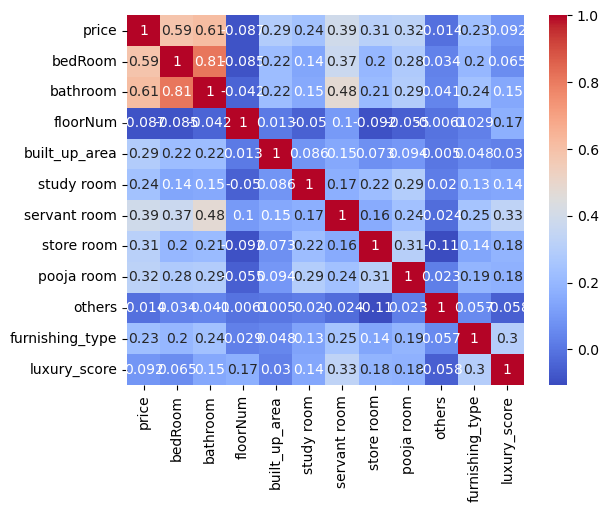

In [37]:
# Corelation between numerical data
sns.heatmap(train_df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')

In [41]:
train_df.select_dtypes(include='number').corr()['price'].sort_values(ascending=False)

price              1.000000
bathroom           0.611337
bedRoom            0.588920
servant room       0.393022
pooja room         0.323228
store room         0.310670
built_up_area      0.290228
study room         0.240678
furnishing_type    0.227185
luxury_score       0.092311
others            -0.014075
floorNum          -0.087089
Name: price, dtype: float64

In [13]:
# cols in question

# numerical -> luxury_score, others, floorNum
# categorical -> property_type, sector, agePossession